# Détection du glaucome à partir d’images du fond d’œil

This notebook is adapted to the folder structure:

- `C:\Users\hp\Documents\eyepac-light-v2-512-jpg\train`
- `C:\Users\hp\Documents\eyepac-light-v2-512-jpg\validation`
- `C:\Users\hp\Documents\eyepac-light-v2-512-jpg\test`

Each split contains two folders:

- `NRG`
- `RG`

This notebook uses:

- VGG16 transfer learning
- image augmentation
- class weighting
- fine-tuning
- threshold tuning based on **F1-score of the positive class**

## 1. Importation des bibliothèques

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## 2. Initialisation des paramètres aléatoires

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

## 3. Chargement et organisation des données

In [ ]:
BASE_PATH = r"eyepac-light-v2-512-jpg"

train_dir = os.path.join(BASE_PATH, "train")
val_dir = os.path.join(BASE_PATH, "validation")
test_dir = os.path.join(BASE_PATH, "test")

print("Base exists:", os.path.exists(BASE_PATH))
print("Train exists:", os.path.exists(train_dir))
print("Validation exists:", os.path.exists(val_dir))
print("Test exists:", os.path.exists(test_dir))

print("Base content:", os.listdir(BASE_PATH))
print("Train classes:", os.listdir(train_dir))
print("Validation classes:", os.listdir(val_dir))
print("Test classes:", os.listdir(test_dir))

Base exists: True
Train exists: True
Validation exists: True
Test exists: True
Base content: ['metadata.csv', 'test', 'train', 'validation']
Train classes: ['NRG', 'RG']
Validation classes: ['NRG', 'RG']
Test classes: ['NRG', 'RG']


## 4. Paramètres du modèle et des images

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

## 5. Prétraitement et augmentation des images

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.9, 1.1)
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_data.class_indices)

Found 8000 images belonging to 2 classes.
Found 770 images belonging to 2 classes.
Found 770 images belonging to 2 classes.
Class indices: {'NRG': 0, 'RG': 1}


## 6. Calcul des poids de classes

In [6]:
y_train = train_data.classes

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight = dict(zip(classes, weights))

print("Class weights:", class_weight)

Class weights: {np.int32(0): np.float64(1.0), np.int32(1): np.float64(1.0)}


## 7. Construction du modèle basé sur VGG16

In [7]:
base_model = VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 8. Définition des callbacks

In [8]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

## 9. Entraînement du modèle (phase 1)

In [9]:
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 457s 912ms/step - accuracy: 0.6044 - loss: 0.9682 - val_accuracy: 0.7143 - val_loss: 0.5929 - learning_rate: 1.0000e-04
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 447s 893ms/step - accuracy: 0.6700 - loss: 0.6376 - val_accuracy: 0.7442 - val_loss: 0.5324 - learning_rate: 1.0000e-04
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 447s 894ms/step - accuracy: 0.7013 - loss: 0.5868 - val_accuracy: 0.7675 - val_loss: 0.5177 - learning_rate: 1.0000e-04
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 445s 891ms/step - accuracy: 0.7226 - loss: 0.5544 - val_accuracy: 0.7688 - val_loss: 0.5015 - learning_rate: 1.0000e-04
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 449s 897ms/step - accuracy: 0.7325 - loss: 0.5462 - val_accuracy: 0.7714 - val_loss: 0.5010 - learning_rate: 1.0000e-04
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 445s 890ms/step - accuracy: 0.7369 - loss: 0.5267 - val_accuracy: 0.7727 - val_loss: 0.4887 - learning_rate: 1.0000e-04
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 

## 10. Fine-tuning du modèle

In [10]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 540s 1s/step - accuracy: 0.7921 - loss: 0.4491 - val_accuracy: 0.8247 - val_loss: 0.4053 - learning_rate: 1.0000e-05
Epoch 2/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 528s 1s/step - accuracy: 0.8219 - loss: 0.3988 - val_accuracy: 0.8208 - val_loss: 0.4398 - learning_rate: 1.0000e-05
Epoch 3/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 519s 1s/step - accuracy: 0.8406 - loss: 0.3574 - val_accuracy: 0.8558 - val_loss: 0.3437 - learning_rate: 1.0000e-05
Epoch 4/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 516s 1s/step - accuracy: 0.8593 - loss: 0.3322 - val_accuracy: 0.8571 - val_loss: 0.3191 - learning_rate: 1.0000e-05
Epoch 5/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 517s 1s/step - accuracy: 0.8670 - loss: 0.3095 - val_accuracy: 0.8662 - val_loss: 0.3102 - learning_rate: 1.0000e-05
Epoch 6/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 515s 1s/step - accuracy: 0.8827 - loss: 0.2831 - val_accuracy: 0.8701 - val_loss: 0.3154 - learning_rate: 1.0000e-05
Epoch 7/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 519s 1s/step - accuracy: 

## 11. Prédiction sur les données de test

In [11]:
test_data.reset()
y_pred_prob = model.predict(test_data, verbose=1).ravel()
y_true = test_data.classes

print("Number of test labels:", len(y_true))
print("Number of predicted probabilities:", len(y_pred_prob))

49/49 ━━━━━━━━━━━━━━━━━━━━ 40s 809ms/step
Number of test labels: 770
Number of predicted probabilities: 770


## 12. Ajustement du seuil de décision (Threshold tuning)

This tests multiple thresholds and selects the one with the best **F1-score** for the positive class.

In [12]:
thresholds = np.arange(0.20, 0.81, 0.05)
results = []

print("\n=== Test des seuils ===")
for t in thresholds:
    y_pred_tmp = (y_pred_prob >= t).astype(int)

    acc = accuracy_score(y_true, y_pred_tmp)
    prec = precision_score(y_true, y_pred_tmp, pos_label=1, zero_division=0)
    rec = recall_score(y_true, y_pred_tmp, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred_tmp, pos_label=1, zero_division=0)

    results.append([t, acc, prec, rec, f1])

    print(
        f"Seuil={t:.2f} | "
        f"Accuracy={acc:.4f} | "
        f"Precision_positive={prec:.4f} | "
        f"Recall_positive={rec:.4f} | "
        f"F1_positive={f1:.4f}"
    )

results_df = pd.DataFrame(
    results,
    columns=["threshold", "accuracy", "precision_positive", "recall_positive", "f1_positive"]
)

print("\nRésultats des seuils :")
print(results_df)

best_row = results_df.loc[results_df["f1_positive"].idxmax()]
best_threshold = float(best_row["threshold"])

print("\nMeilleur seuil selon F1 positive :", best_threshold)
print(best_row)


=== Test des seuils ===
Seuil=0.20 | Accuracy=0.8338 | Precision_positive=0.7683 | Recall_positive=0.9558 | F1_positive=0.8519
Seuil=0.25 | Accuracy=0.8468 | Precision_positive=0.7908 | Recall_positive=0.9429 | F1_positive=0.8602
Seuil=0.30 | Accuracy=0.8545 | Precision_positive=0.8040 | Recall_positive=0.9377 | F1_positive=0.8657
Seuil=0.35 | Accuracy=0.8649 | Precision_positive=0.8200 | Recall_positive=0.9351 | F1_positive=0.8738
Seuil=0.40 | Accuracy=0.8636 | Precision_positive=0.8256 | Recall_positive=0.9221 | F1_positive=0.8712
Seuil=0.45 | Accuracy=0.8649 | Precision_positive=0.8353 | Recall_positive=0.9091 | F1_positive=0.8706
Seuil=0.50 | Accuracy=0.8649 | Precision_positive=0.8435 | Recall_positive=0.8961 | F1_positive=0.8690
Seuil=0.55 | Accuracy=0.8688 | Precision_positive=0.8586 | Recall_positive=0.8831 | F1_positive=0.8707
Seuil=0.60 | Accuracy=0.8662 | Precision_positive=0.8653 | Recall_positive=0.8675 | F1_positive=0.8664
Seuil=0.65 | Accuracy=0.8779 | Precision_positiv

## 13. Évaluation des performances du modèle

The positive class here is whatever Keras maps to label `1`.
Check `train_data.class_indices` above to confirm whether that corresponds to `RG` or `NRG`.

In [13]:
y_pred = (y_pred_prob >= best_threshold).astype(int)

print("\n=== Évaluation finale ===")
print("Seuil final utilisé :", best_threshold)
print("Accuracy :", accuracy_score(y_true, y_pred))

print("\nConfusion Matrix :")
cm = confusion_matrix(y_true, y_pred)
print(cm)

print("\nClassification Report :")
report = classification_report(
    y_true,
    y_pred,
    target_names=list(test_data.class_indices.keys())
)
print(report)


=== Évaluation finale ===
Seuil final utilisé : 0.6499999999999999
Accuracy : 0.8779220779220779

Confusion Matrix :
[[344  41]
 [ 53 332]]

Classification Report :
              precision    recall  f1-score   support

         NRG       0.87      0.89      0.88       385
          RG       0.89      0.86      0.88       385

    accuracy                           0.88       770
   macro avg       0.88      0.88      0.88       770
weighted avg       0.88      0.88      0.88       770



## 14. Analyse des courbes d’apprentissage

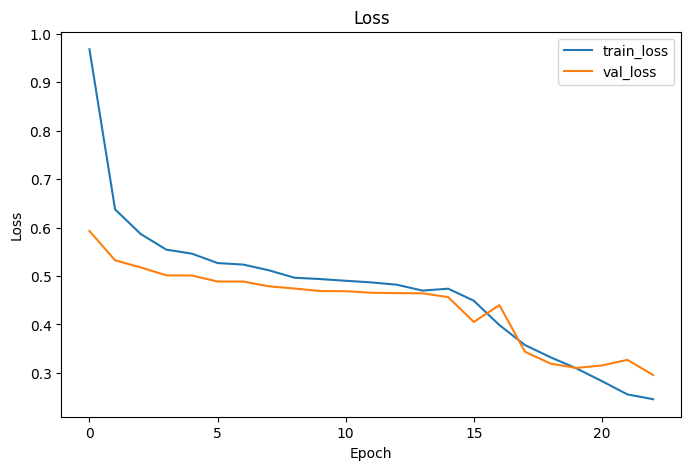

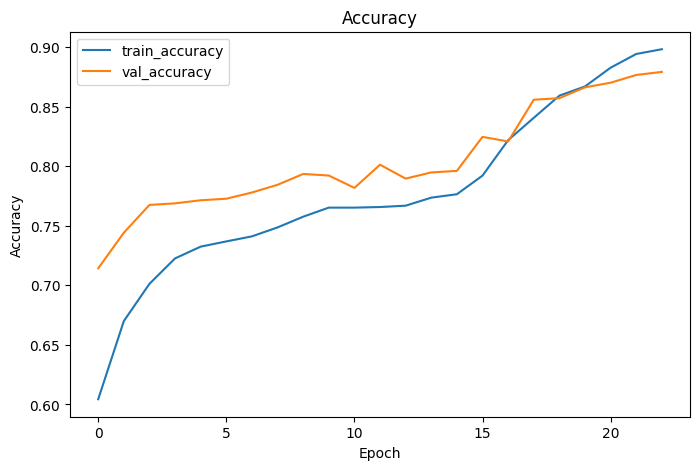

In [14]:
train_loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]
train_acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_acc, label="train_accuracy")
plt.plot(val_acc, label="val_accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 15. Analyse de l’impact du seuil de décision

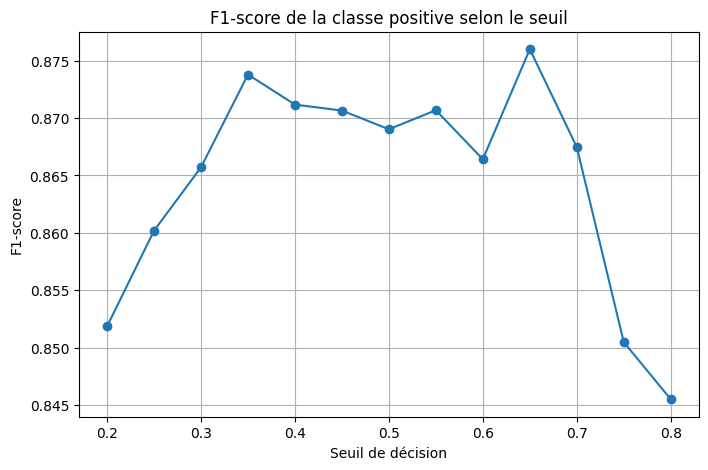

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["threshold"], results_df["f1_positive"], marker="o")
plt.title("F1-score de la classe positive selon le seuil")
plt.xlabel("Seuil de décision")
plt.ylabel("F1-score")
plt.grid(True)
plt.show()

## 16. Sauvegarde du modèle

In [16]:
model.save("eyepacs_airogs_vgg16_best_threshold.h5")
print("Model saved as eyepacs_airogs_vgg16_best_threshold.h5")

Model saved as eyepacs_airogs_vgg16_best_threshold.h5
